# RIA Calcium Imaging

## Notebook Setup
In this section, we'll set ourselves up for success by setting up our Python environment appropriately, importing the Python libraries we'll be using, and downloading the raw data from Google Drive.

In [1]:
# Importing the necessary Python libraries
from __future__ import annotations

import json
import os
import random
import re
import shutil
import time
import zipfile
from pathlib import Path

import cv2
import gdown
import h5py
import matplotlib.pyplot as plt
import numpy as np
import numpy.linalg as la
import pandas as pd
import tifffile
import torch
from PIL import Image
from scipy.ndimage import binary_dilation, distance_transform_edt, gaussian_filter1d
from skimage.morphology import skeletonize
from tqdm.notebook import tqdm

from sam2.build_sam import build_sam2_video_predictor_hf

In [2]:
# Setting the root of the working directory
WORK_DIR_ROOT = '..'

# Setting the working directories used throughout this notebook
raw_files_dir = f'{WORK_DIR_ROOT}/data/raw_files'
processed_files_dir = f'{WORK_DIR_ROOT}/data/processed_files/RIA_calcium_imaging'
processed_base_images_files_dir = f'{processed_files_dir}/base_images'
crop_outputs_dir = Path(processed_files_dir) / 'crop_outputs'
segmentation_outputs_dir = Path(processed_files_dir) / 'segmentation_outputs'
head_segmentation_outputs_dir = Path(processed_files_dir) / 'head_segmentation_outputs'
final_data_dir = Path(processed_files_dir) / 'final_data'
final_cutouts_dir = Path(processed_files_dir) / 'final_cutouts'
metrics_output_dir = Path(processed_files_dir) / 'metrics'

# Setting prompt asset paths
prompt_dir = Path(WORK_DIR_ROOT) / 'RIA_calcium_imaging' / 'prompt_frames'
prompt_data_file = Path(WORK_DIR_ROOT) / 'RIA_calcium_imaging' / 'prompt_data.json'

# Creating required directories (if not already created)
os.makedirs(raw_files_dir, exist_ok=True)
os.makedirs(processed_base_images_files_dir, exist_ok=True)
crop_outputs_dir.mkdir(parents=True, exist_ok=True)
segmentation_outputs_dir.mkdir(parents=True, exist_ok=True)
head_segmentation_outputs_dir.mkdir(parents=True, exist_ok=True)
final_data_dir.mkdir(parents=True, exist_ok=True)
final_cutouts_dir.mkdir(parents=True, exist_ok=True)
metrics_output_dir.mkdir(parents=True, exist_ok=True)

## Downloading the Raw TIFF Files

In [3]:
# Setting the raw Google Drive doc ID and file URL
RAW_FILE_DOC_ID = '1UTYRcgheRP1eMXw71CNgh9-em2MigdDb'
gdrive_file_url = f'https://drive.google.com/uc?id={RAW_FILE_DOC_ID}'

# Checking whether raw files are already present (ignoring .gitkeep)
existing_raw_files = [
    path for path in Path(raw_files_dir).iterdir() if path.name != '.gitkeep'
 ]

# Downloading and extracting only when the raw files directory is empty or only has .gitkeep
if not existing_raw_files:

    # Downloading the raw files from Google Drive
    gdown.download(
        url = gdrive_file_url,
        output = f'{raw_files_dir}/samples.zip'
    )

    # Setting the .zip filepath
    zip_path = Path(f'{raw_files_dir}/samples.zip')

    # Setting the prefix associated to all the raw TIF files
    RAW_FILE_PREFIX = "06.27.25 CONFOCAL VID_DYS1AH DAY 5 CRAWL "

    # Interacting with the ZIP file downloaded from Google Drive
    with zipfile.ZipFile(zip_path) as z:

        # Iterating over each TIF file in the raw ZIP
        for member in z.namelist():

            # Checking if the file is in the "sample images/" directory and ends with ".tif"
            if member.startswith('sample images/') and member.endswith('.tif'):

                # Getting the original name of the file
                original_name = Path(member).name

                # Setting a new name for the file by stripping the prefix from the file
                new_name = original_name.replace(RAW_FILE_PREFIX, '', 1)

                # Extracting the contents of the file from the ZIP
                target = zip_path.parent / new_name
                with z.open(member) as src, open(target, 'wb') as destination:
                    destination.write(src.read())

    # Deleting the original ZIP file as it is no longer needed
    zip_path.unlink()
else:
    print('Raw files already exist in raw_files_dir; skipping download and extraction.')

Raw files already exist in raw_files_dir; skipping download and extraction.


## Processing TIFFs into JPEG Frame Directories
Each raw TIFF stack is converted into a dedicated directory of numbered JPEG frames. Global min/max normalization is applied across all frames within each stack to preserve relative brightness — essential for downstream calcium imaging analysis.

In [4]:
# Checking whether processed frame directories already exist (ignoring .gitkeep)
existing_processed_files = [
    path for path in Path(processed_base_images_files_dir).iterdir()
    if path.name != '.gitkeep'
]

# Processing raw TIFF files only when the processed directory is empty
if not existing_processed_files:

    # Iterating over all raw TIFF files
    for raw_file_name in sorted(os.listdir(raw_files_dir)):

        # Skipping non-TIFF files
        if not raw_file_name.lower().endswith(('.tif', '.tiff')):
            continue

        tiff_path = os.path.join(raw_files_dir, raw_file_name)

        with tifffile.TiffFile(tiff_path) as tif:
            total_frames = len(tif.pages)
            if total_frames == 0:
                print(f'Skipping {raw_file_name}: empty TIFF')
                continue

            # Computing global min/max across all frames for consistent brightness normalization
            global_min = float('inf')
            global_max = float('-inf')
            for page in tif.pages:
                frame = page.asarray()
                global_min = min(global_min, float(np.min(frame)))
                global_max = max(global_max, float(np.max(frame)))

            # Creating an output directory named after the TIFF stem
            raw_file_stem = Path(raw_file_name).stem
            video_output_dir = Path(processed_base_images_files_dir) / raw_file_stem
            video_output_dir.mkdir(parents=True, exist_ok=True)

            # Exporting each frame as a globally-normalized JPEG
            for frame_idx in range(total_frames):
                frame = tif.pages[frame_idx].asarray()

                if global_max == global_min:
                    frame_8bit = np.zeros_like(frame, dtype=np.uint8)
                else:
                    frame_adjusted = frame.astype(np.float64) - global_min
                    scaling_factor = 255.0 / (global_max - global_min)
                    frame_8bit = (frame_adjusted * scaling_factor).astype(np.uint8)

                # Converting grayscale to BGR for consistent JPEG output
                if frame_8bit.ndim == 2:
                    frame_8bit = cv2.cvtColor(frame_8bit, cv2.COLOR_GRAY2BGR)

                dest_path = video_output_dir / f'{frame_idx:06d}.jpg'
                cv2.imwrite(str(dest_path), frame_8bit, [cv2.IMWRITE_JPEG_QUALITY, 95])

            print(f'Converted {raw_file_name}: {total_frames} frames -> {video_output_dir.name}/')
else:
    print('Processed frame directories already exist; skipping TIFF-to-JPEG conversion.')

Converted 5_t065_ch01.tif: 1 frames -> 5_t065_ch01/
Converted 5_t065_ch02.tif: 1 frames -> 5_t065_ch02/
Converted 5_t065_ch03.tif: 1 frames -> 5_t065_ch03/
Converted 5_t066_ch00.tif: 1 frames -> 5_t066_ch00/
Converted 5_t066_ch01.tif: 1 frames -> 5_t066_ch01/
Converted 5_t066_ch02.tif: 1 frames -> 5_t066_ch02/
Converted 5_t066_ch03.tif: 1 frames -> 5_t066_ch03/
Converted 5_t067_ch00.tif: 1 frames -> 5_t067_ch00/
Converted 5_t067_ch01.tif: 1 frames -> 5_t067_ch01/
Converted 5_t067_ch02.tif: 1 frames -> 5_t067_ch02/
Converted 5_t067_ch03.tif: 1 frames -> 5_t067_ch03/
Converted 5_t068_ch00.tif: 1 frames -> 5_t068_ch00/
Converted 5_t068_ch01.tif: 1 frames -> 5_t068_ch01/
Converted 5_t068_ch02.tif: 1 frames -> 5_t068_ch02/
Converted 5_t068_ch03.tif: 1 frames -> 5_t068_ch03/
Converted 5_t069_ch00.tif: 1 frames -> 5_t069_ch00/
Converted 5_t069_ch01.tif: 1 frames -> 5_t069_ch01/
Converted 5_t069_ch02.tif: 1 frames -> 5_t069_ch02/
Converted 5_t069_ch03.tif: 1 frames -> 5_t069_ch03/
Converted 5_

### Selecting a Test Video

Available video directories: ['5_t065_ch01', '5_t065_ch02', '5_t065_ch03', '5_t066_ch00', '5_t066_ch01', '5_t066_ch02', '5_t066_ch03', '5_t067_ch00', '5_t067_ch01', '5_t067_ch02', '5_t067_ch03', '5_t068_ch00', '5_t068_ch01', '5_t068_ch02', '5_t068_ch03', '5_t069_ch00', '5_t069_ch01', '5_t069_ch02', '5_t069_ch03', '5_t070_ch00', '5_t070_ch01', '5_t070_ch02', '5_t129_ch02', '5_t129_ch03', '5_t130_ch00', '5_t130_ch01', '5_t130_ch02', '5_t130_ch03', '5_t131_ch00', '5_t131_ch01', '5_t131_ch02', '5_t131_ch03', '5_t132_ch00', '5_t132_ch01', '5_t132_ch02', '5_t132_ch03', '5_t133_ch00', '5_t133_ch01', '5_t133_ch02', '5_t133_ch03', '5_t134_ch00', '5_t134_ch01', '5_t134_ch02', '5_t134_ch03']
Selected test video: 5_t065_ch01
Total frames: 1, frame size: (128, 128)


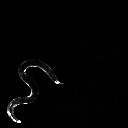

In [5]:
# Listing all available video frame directories
video_dirs = sorted([
    d for d in Path(processed_base_images_files_dir).iterdir()
    if d.is_dir() and d.name != '.gitkeep'
])

if not video_dirs:
    raise FileNotFoundError(
        f'No video frame directories found in: {processed_base_images_files_dir}'
    )

# Selecting the first available video directory for processing
video_dir = str(video_dirs[0])
video_name = Path(video_dir).name
print(f'Available video directories: {[d.name for d in video_dirs]}')
print(f'Selected test video: {video_name}')

# Loading and displaying a sample frame from the middle of the selected video
frame_names = sorted(
    [f for f in os.listdir(video_dir) if f.lower().endswith(('.jpg', '.jpeg'))],
    key=lambda p: int(os.path.splitext(p)[0])
)

sample_frame_path = os.path.join(video_dir, frame_names[len(frame_names) // 2])
sample_frame = cv2.imread(sample_frame_path)
print(f'Total frames: {len(frame_names)}, frame size: {sample_frame.shape[:2]}')
Image.fromarray(cv2.cvtColor(sample_frame, cv2.COLOR_BGR2RGB))

## Cropping the RIA Region
Using the SAM2 video predictor, we identify the RIA region in the video by prompting the model on the last frame and propagating the detection backward through all frames. All frames are then cropped to a fixed window centered on the detected region.

### Loading the SAM2 Video Predictor

In [6]:
# Detecting the hardware device
if torch.cuda.is_available():
    device = torch.device('cuda')
    torch.autocast(device_type='cuda', dtype=torch.bfloat16).__enter__()
    if torch.cuda.get_device_properties(0).major >= 8:
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

print(f'Current hardware device type: {device}')

# Loading the SAM2 video predictor from Hugging Face
predictor = build_sam2_video_predictor_hf('facebook/sam2.1-hiera-large', device=device)

Current hardware device type: mps


sam2.1_hiera_large.pt:   0%|          | 0.00/898M [00:00<?, ?B/s]

### Creating Helper Functions for Cropping

In [7]:
# Visualizing a segmentation mask on a plot
def show_mask(mask, ax, obj_id=None, random_color=False):
    if random_color:
        color = np.concatenate([np.random.random(3), np.array([0.6])], axis=0)
    else:
        cmap = plt.get_cmap('tab10')
        cmap_idx = 0 if obj_id is None else obj_id
        color = np.array([*cmap(cmap_idx)[:3], 0.6])
    h, w = mask.shape[-2:]
    mask_image = mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    ax.imshow(mask_image)


# Visualizing prompt points on a plot
def show_points(coords, labels, ax, marker_size=20):
    pos_points = coords[labels == 1]
    neg_points = coords[labels == 0]
    ax.scatter(pos_points[:, 0], pos_points[:, 1], color='green', marker='*',
               s=marker_size, edgecolor='white', linewidth=1.25)
    ax.scatter(neg_points[:, 0], neg_points[:, 1], color='red', marker='*',
               s=marker_size, edgecolor='white', linewidth=1.25)


# Calculating a fixed crop window centered on the RIA detection across all frames
def calculate_fixed_crop_window(video_segments, original_size, crop_size):
    orig_height, orig_width = original_size
    centers = []
    empty_masks = 0
    total_masks = 0

    for frame_num in sorted(video_segments.keys()):
        mask = next(iter(video_segments[frame_num].values()))
        total_masks += 1
        y_coords, x_coords = np.where(mask[0])

        if len(x_coords) > 0 and len(y_coords) > 0:
            center_x = (x_coords.min() + x_coords.max()) // 2
            center_y = (y_coords.min() + y_coords.max()) // 2
            centers.append((center_x, center_y))
        else:
            empty_masks += 1
            centers.append((orig_width // 2, orig_height // 2))

    # Falling back to the average center when some masks are empty
    if empty_masks > 0:
        avg_center_x = sum(c[0] for c in centers) // len(centers)
        avg_center_y = sum(c[1] for c in centers) // len(centers)
        centers = [(avg_center_x, avg_center_y)] * len(centers)

    crop_windows = []
    for center_x, center_y in centers:
        left = max(0, center_x - crop_size // 2)
        top = max(0, center_y - crop_size // 2)
        right = min(orig_width, left + crop_size)
        bottom = min(orig_height, top + crop_size)

        if right == orig_width:
            left = right - crop_size
        if bottom == orig_height:
            top = bottom - crop_size

        crop_windows.append((left, top, right, bottom))

    return crop_windows, (crop_size, crop_size), empty_masks, total_masks


# Applying the fixed crop to all frames and saving to the output directory
def process_frames_fixed_crop(input_folder, output_folder, video_segments, original_size, crop_size):
    frame_files = sorted([f for f in os.listdir(input_folder) if f.lower().endswith('.jpg')])
    if not frame_files:
        raise ValueError('No jpg files found in the input folder')

    os.makedirs(output_folder, exist_ok=True)

    crop_windows, (crop_height, crop_width), empty_masks, total_masks = calculate_fixed_crop_window(
        video_segments, original_size, crop_size
    )

    if not crop_windows:
        orig_height, orig_width = original_size
        left = max(0, (orig_width - crop_width) // 2)
        top = max(0, (orig_height - crop_height) // 2)
        right = min(orig_width, left + crop_width)
        bottom = min(orig_height, top + crop_height)
        crop_windows = [(left, top, right, bottom)] * len(frame_files)
    elif len(crop_windows) < len(frame_files):
        crop_windows.extend([crop_windows[-1]] * (len(frame_files) - len(crop_windows)))

    print(f'Empty masks: {empty_masks}/{total_masks}, Crop size: {crop_height}x{crop_width}')

    for idx, frame_file in enumerate(tqdm(frame_files, desc='Cropping frames')):
        frame = cv2.imread(os.path.join(input_folder, frame_file))
        left, top, right, bottom = crop_windows[idx]

        cropped_frame = frame[top:bottom, left:right]
        if cropped_frame.shape[:2] != (crop_height, crop_width):
            cropped_frame = cv2.resize(cropped_frame, (crop_width, crop_height))

        cv2.imwrite(os.path.join(output_folder, frame_file), cropped_frame)

    print(f'Cropped frames saved to: {output_folder}')
    return len(frame_files), (crop_height, crop_width)

### Running the RIA Region Crop

frame loading (JPEG): 100%|██████████| 1/1 [00:00<00:00, 46.53it/s]
/Users/dkhundley/Documents/Repositories/random-repos/TWARDISv0.1/.venv/lib/python3.12/site-packages/sam2/sam2_video_predictor.py:786: UserWarning: cannot import name '_C' from 'sam2' (/Users/dkhundley/Documents/Repositories/random-repos/TWARDISv0.1/.venv/lib/python3.12/site-packages/sam2/__init__.py)

Skipping the post-processing step due to the error above. You can still use SAM 2 and it's OK to ignore the error above, although some post-processing functionality may be limited (which doesn't affect the results in most cases; see https://github.com/facebookresearch/sam2/blob/main/INSTALL.md).
  pred_masks_gpu = fill_holes_in_mask_scores(


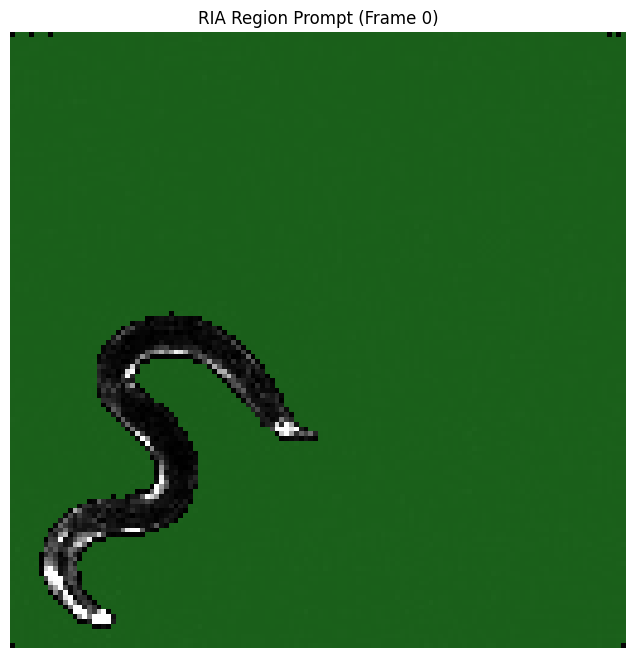

propagate in video: 0it [00:00, ?it/s]

Propagated masks across 1 frames
Empty masks: 0/1, Crop size: 110x110


Cropping frames:   0%|          | 0/1 [00:00<?, ?it/s]

Cropped frames saved to: ../data/processed_files/RIA_calcium_imaging/crop_outputs/5_t065_ch01_crop
Cropped frame size: (110, 110)


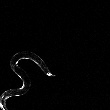

In [8]:
# Setting the crop size and output directory
CROP_SIZE = 110
crop_video_dir = str(crop_outputs_dir / f'{video_name}_crop')

# Checking if this video has already been cropped
if os.path.exists(crop_video_dir) and any(
    f.lower().endswith('.jpg') for f in os.listdir(crop_video_dir)
):
    print(f'Cropped frames already exist at {crop_video_dir}; skipping crop step.')
else:
    # Initializing the SAM2 video predictor on the selected video
    inference_state = predictor.init_state(video_path=video_dir)

    # Prompting on the last frame with a generic RIA region point
    ann_frame_idx = len(frame_names) - 1
    ann_obj_id = 2
    points = np.array([[250, 315]], dtype=np.float32)
    labels = np.array([1], np.int32)

    _, out_obj_ids, out_mask_logits = predictor.add_new_points(
        inference_state=inference_state,
        frame_idx=ann_frame_idx,
        obj_id=ann_obj_id,
        points=points,
        labels=labels,
    )

    # Visualizing the prompt on the annotated frame
    plt.figure(figsize=(10, 8))
    plt.imshow(Image.open(os.path.join(video_dir, frame_names[ann_frame_idx])))
    show_points(points, labels, plt.gca())
    for i, out_obj_id in enumerate(out_obj_ids):
        show_mask((out_mask_logits[i] > 0.0).cpu().numpy(), plt.gca(), obj_id=out_obj_id)
    plt.title(f'RIA Region Prompt (Frame {ann_frame_idx})')
    plt.axis('off')
    plt.show()

    # Propagating the mask backward through all frames
    video_segments = {}
    video_segments[ann_frame_idx] = {
        out_obj_id: (out_mask_logits[i] > 0.0).cpu().numpy()
        for i, out_obj_id in enumerate(out_obj_ids)
    }

    for out_frame_idx, out_obj_ids_prop, out_mask_logits_prop in predictor.propagate_in_video(
        inference_state, start_frame_idx=ann_frame_idx, reverse=True
    ):
        video_segments[out_frame_idx] = {
            out_obj_id: (out_mask_logits_prop[i] > 0.0).cpu().numpy()
            for i, out_obj_id in enumerate(out_obj_ids_prop)
        }

    print(f'Propagated masks across {len(video_segments)} frames')

    # Cropping all frames to a fixed window around the detected RIA region
    first_frame = cv2.imread(os.path.join(video_dir, frame_names[0]))
    original_size = first_frame.shape[:2]
    process_frames_fixed_crop(video_dir, crop_video_dir, video_segments, original_size, CROP_SIZE)

# Displaying a sample cropped frame
crop_frame_names = sorted(
    [f for f in os.listdir(crop_video_dir) if f.lower().endswith('.jpg')],
    key=lambda p: int(os.path.splitext(p)[0])
)
sample_crop = cv2.imread(os.path.join(crop_video_dir, crop_frame_names[len(crop_frame_names) // 2]))
print(f'Cropped frame size: {sample_crop.shape[:2]}')
Image.fromarray(cv2.cvtColor(sample_crop, cv2.COLOR_BGR2RGB))

## RIA Compartment Segmentation
With the cropped RIA region frames, we segment individual RIA compartments (nrd, nrv, loop) using pre-defined prompt points and the SAM2 video predictor. Prompt images and their associated point coordinates are stored in `RIA_calcium_imaging/prompt_frames/` and `RIA_calcium_imaging/prompt_data.json`.

### Creating Helper Functions for Segmentation

In [9]:
# Adding prompt frame images to the end of a video directory for SAM2 prompting
def add_prompt_frames_to_video(target_video_dir, source_prompt_dir):
    existing_frames = [
        f for f in os.listdir(target_video_dir)
        if f.lower().endswith(('.jpg', '.jpeg'))
    ]
    last_frame_num = max(int(os.path.splitext(f)[0]) for f in existing_frames)

    prompt_frames = sorted(
        [f for f in os.listdir(source_prompt_dir) if f.lower().endswith(('.jpg', '.jpeg'))],
        key=lambda x: int(os.path.splitext(x)[0])
    )

    frame_mapping = {}
    for i, prompt_frame in enumerate(prompt_frames, start=1):
        new_frame_num = last_frame_num + i
        new_frame_name = f'{new_frame_num:06d}.jpg'
        shutil.copy(
            os.path.join(source_prompt_dir, prompt_frame),
            os.path.join(target_video_dir, new_frame_name)
        )
        frame_mapping[new_frame_num] = int(os.path.splitext(prompt_frame)[0])

    print(f'Added {len(prompt_frames)} prompt frames (total now: {last_frame_num + len(prompt_frames) + 1})')
    return frame_mapping


# Removing prompt frame images from a video directory after segmentation
def remove_prompt_frames_from_video(target_video_dir, frame_mapping):
    for frame_num in frame_mapping:
        frame_path = os.path.join(target_video_dir, f'{frame_num:06d}.jpg')
        if os.path.exists(frame_path):
            os.remove(frame_path)
    print(f'Removed {len(frame_mapping)} prompt frames')


# Adding point prompts for a specific frame and object
def add_prompts_to_state(inference_state, frame_idx, obj_id, points, labels):
    _, out_obj_ids, out_mask_logits = predictor.add_new_points(
        inference_state=inference_state,
        frame_idx=frame_idx,
        obj_id=obj_id,
        points=points,
        labels=labels,
    )
    return out_obj_ids, out_mask_logits


# Analyzing segmentation mask quality across all frames
def analyze_segmentation_masks(video_segments):
    results = {'empty': {}, 'high': {}, 'overlapping': {}}
    total_frames = len(video_segments)

    for frame, mask_dict in video_segments.items():
        mask_ids = [mid for mid in mask_dict if mid is not None]
        for i, mask_id in enumerate(mask_ids):
            mask = mask_dict[mask_id]
            if mask is not None:
                mask_sum = mask.sum()
                if mask_sum == 0:
                    results['empty'].setdefault(frame, []).append(mask_id)
                elif mask_sum >= 800:
                    results['high'].setdefault(frame, []).append(mask_id)

                for j in range(i + 1, len(mask_ids)):
                    other_id = mask_ids[j]
                    other_mask = mask_dict[other_id]
                    if other_mask is not None:
                        overlap = np.sum(np.logical_and(mask, other_mask))
                        if overlap > 0:
                            union = np.sum(np.logical_or(mask, other_mask))
                            iou = overlap / union if union > 0 else 0
                            results['overlapping'].setdefault(frame, []).append(
                                (mask_id, other_id, iou, overlap)
                            )

    for category, frames in results.items():
        count = len(frames)
        pct = (count / total_frames) * 100 if total_frames > 0 else 0
        print(f'Frames with {category} masks: {count}/{total_frames} ({pct:.1f}%)')

    return results


# Saving video segmentation data to an HDF5 file
def save_video_segments_to_h5(video_segments, video_dir_name, output_dir, frame_mapping):
    filename = f'{os.path.basename(video_dir_name)}_riasegmentation.h5'
    output_path = os.path.join(str(output_dir), filename)

    # Excluding prompt frames from saved output
    exclude_frames = set(frame_mapping.keys())
    filtered_segments = {
        frame: segs for frame, segs in video_segments.items()
        if frame not in exclude_frames
    }

    sample_frame = next(iter(filtered_segments.values()))
    object_ids = list(sample_frame.keys())
    sample_mask = next(iter(sample_frame.values()))
    mask_shape = sample_mask.shape

    with h5py.File(output_path, 'w') as f:
        f.attrs['num_frames'] = len(filtered_segments)
        f.attrs['object_ids'] = [str(oid) if oid is not None else 'None' for oid in object_ids]

        for obj_id in object_ids:
            obj_key = str(obj_id) if obj_id is not None else 'None'
            f.create_dataset(
                f'masks/{obj_key}',
                shape=(len(filtered_segments), *mask_shape),
                dtype=bool,
                compression='gzip',
            )

        for i, (frame_idx, objects) in enumerate(sorted(filtered_segments.items(), reverse=True)):
            for obj_id, mask in objects.items():
                obj_key = str(obj_id) if obj_id is not None else 'None'
                f[f'masks/{obj_key}'][i] = mask

    print(f'Saved {len(filtered_segments)} frames to {output_path}')
    return filtered_segments, output_path

### Running Segmentation

In [10]:
# Checking if segmentation already exists for this video
seg_output_file = segmentation_outputs_dir / f'{video_name}_crop_riasegmentation.h5'

if seg_output_file.exists():
    print(f'Segmentation already exists at {seg_output_file}; skipping segmentation step.')
else:
    # Adding prompt frames to the cropped video directory
    frame_mapping = add_prompt_frames_to_video(crop_video_dir, str(prompt_dir))

    # Loading prompt data from JSON
    with open(str(prompt_data_file), 'r') as f:
        prompt_data = json.load(f)

    # Converting prompt coordinates to numpy arrays
    for frame_num in prompt_data:
        for obj_id in prompt_data[frame_num]:
            prompt_data[frame_num][obj_id]['points'] = np.array(
                prompt_data[frame_num][obj_id]['points'], dtype=np.float32
            )
            prompt_data[frame_num][obj_id]['labels'] = np.array(
                prompt_data[frame_num][obj_id]['labels'], dtype=np.int32
            )

    # Refreshing frame list and initializing SAM2 predictor on the cropped video
    seg_frame_names = sorted(
        [p for p in os.listdir(crop_video_dir) if p.lower().endswith(('.jpg', '.jpeg'))],
        key=lambda p: int(os.path.splitext(p)[0])
    )
    inference_state = predictor.init_state(video_path=crop_video_dir)

    # Adding prompts for each prompt frame
    for new_frame_num, original_frame_num in frame_mapping.items():
        if str(original_frame_num) in prompt_data:
            for obj_id, obj_data in prompt_data[str(original_frame_num)].items():
                add_prompts_to_state(
                    inference_state, new_frame_num, int(obj_id),
                    obj_data['points'], obj_data['labels']
                )
                time.sleep(0.02)

    # Propagating masks backward from the last prompt frame
    video_segments = {}
    last_frame_idx = max(frame_mapping.keys())

    for out_frame_idx, out_obj_ids, out_mask_logits in predictor.propagate_in_video(
        inference_state, start_frame_idx=last_frame_idx, reverse=True
    ):
        video_segments[out_frame_idx] = {
            out_obj_id: (out_mask_logits[i] > 0.0).cpu().numpy()
            for i, out_obj_id in enumerate(out_obj_ids)
        }

    # Removing prompt frames from the video directory
    remove_prompt_frames_from_video(crop_video_dir, frame_mapping)

    # Analyzing segmentation quality
    analyze_segmentation_masks(video_segments)

    # Saving segmentation to H5
    filtered_video_segments, seg_h5_path = save_video_segments_to_h5(
        video_segments, crop_video_dir, segmentation_outputs_dir, frame_mapping
    )

    print(f'RIA compartment segmentation complete for {video_name}')

Added 1 prompt frames (total now: 2)


propagate in video: 100%|██████████| 2/2 [00:01<00:00,  1.21it/s]

Removed 1 prompt frames
Frames with empty masks: 0/2 (0.0%)
Frames with high masks: 2/2 (100.0%)
Frames with overlapping masks: 2/2 (100.0%)
Saved 1 frames to ../data/processed_files/RIA_calcium_imaging/segmentation_outputs/5_t065_ch01_crop_riasegmentation.h5
RIA compartment segmentation complete for 5_t065_ch01


## Extracting RIA Brightness and Orientation
From the segmented compartment masks, we extract per-compartment brightness measurements with background correction and determine the worm's left/right orientation.

### Creating Helper Functions for Brightness Extraction

In [11]:
# Loading cleaned segmentation masks from an H5 file
def load_cleaned_segments_from_h5(filename):
    cleaned_segments = {}
    with h5py.File(filename, 'r') as f:
        num_frames = f.attrs['num_frames']
        object_ids = f.attrs['object_ids']
        masks_group = f['masks']

        for frame_idx in range(num_frames):
            frame_data = {}
            for obj_id in object_ids:
                mask = (masks_group[str(obj_id)][frame_idx] > 0).astype(bool)

                # Using integer keys when possible for consistent downstream use
                try:
                    key = int(obj_id)
                except (ValueError, TypeError):
                    key = obj_id
                frame_data[key] = mask
            cleaned_segments[frame_idx] = frame_data

    print(f'{num_frames} frames loaded from {filename}')
    return cleaned_segments


# Sampling background pixel coordinates far from any mask
def get_background_sample(frame_masks, image_shape, num_samples=100, min_distance=40):
    combined_mask = np.zeros(image_shape[-2:] if len(image_shape) > 2 else image_shape, dtype=bool)
    for mask in frame_masks.values():
        combined_mask |= mask.squeeze()

    distance_map = distance_transform_edt(~combined_mask)
    valid_bg = distance_map >= min_distance
    valid_coords = np.column_stack(np.where(valid_bg))

    if len(valid_coords) < num_samples:
        return valid_coords

    sampled_indices = random.sample(range(len(valid_coords)), num_samples)
    return valid_coords[sampled_indices]


# Computing mean brightness per mask region and background
def calculate_mean_values_and_pixel_counts(image, masks, background_coordinates):
    mean_values = {}
    pixel_counts = {}

    bg_pixel_values = image[background_coordinates[:, 0], background_coordinates[:, 1]]
    mean_values['background'] = float(np.mean(bg_pixel_values))

    for obj_id, mask in masks.items():
        mask_squeezed = mask.squeeze()
        mask_pixel_values = image[mask_squeezed]
        mean_values[obj_id] = float(np.mean(mask_pixel_values)) if len(mask_pixel_values) > 0 else 0.0
        pixel_counts[obj_id] = int(np.sum(mask_squeezed))

    return mean_values, pixel_counts


# Building a wide-format DataFrame with background-corrected brightness values
def create_brightness_dataframe(mean_values, pixel_counts):
    data = {'frame': []}

    all_objects = set()
    for frame_data in mean_values.values():
        all_objects.update(frame_data.keys())
    all_objects.discard('background')

    for obj in all_objects:
        data[str(obj)] = []
        data[f'{obj}_bg_corrected'] = []
        data[f'{obj}_pixel_count'] = []

    for frame_idx, frame_data in sorted(mean_values.items()):
        data['frame'].append(frame_idx)
        bg_value = frame_data['background']
        frame_pixel_counts = pixel_counts.get(frame_idx, {})

        for obj in all_objects:
            obj_value = frame_data.get(obj, np.nan)
            data[str(obj)].append(obj_value)
            data[f'{obj}_bg_corrected'].append(
                obj_value - bg_value if pd.notnull(obj_value) else np.nan
            )
            data[f'{obj}_pixel_count'].append(frame_pixel_counts.get(obj, 0))

    df = pd.DataFrame(data)

    # Adding background column
    background_values = [mean_values[fi]['background'] for fi in sorted(mean_values.keys())]
    df['background'] = background_values
    return df


# Determining left/right orientation from the first segmentation frame
def get_relative_position(first_frame):
    numeric_keys = [k for k in first_frame if isinstance(k, (int, np.integer))]

    preferred_pair = (2, 4)
    if all(k in first_frame for k in preferred_pair):
        left_ref_id, right_ref_id = preferred_pair
    elif len(numeric_keys) >= 2:
        sorted_keys = sorted(numeric_keys)
        left_ref_id, right_ref_id = sorted_keys[0], sorted_keys[1]
    else:
        return 'unknown'

    def get_centroid(mask):
        m = mask.squeeze() if mask.ndim > 2 else mask
        y_idx, x_idx = np.where(m)
        return (float(np.mean(x_idx)), float(np.mean(y_idx))) if len(x_idx) > 0 else None

    c_left = get_centroid(first_frame[left_ref_id])
    c_right = get_centroid(first_frame[right_ref_id])

    if c_left is None or c_right is None:
        return 'unknown'

    return 'left' if c_right[0] < c_left[0] else 'right'

### Extracting Brightness and Saving Data

In [12]:
# Loading the segmentation data
seg_file = str(segmentation_outputs_dir / f'{video_name}_crop_riasegmentation.h5')
cleaned_segments = load_cleaned_segments_from_h5(seg_file)

# Loading a single frame image for brightness extraction
def load_frame_image(frame_idx):
    image_path = os.path.join(crop_video_dir, f'{frame_idx:06d}.jpg')
    return cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

# Processing all frames to extract brightness
first_frame_data = next(iter(cleaned_segments.values()))
first_mask = next(iter(first_frame_data.values()))
image_shape = first_mask.shape

mean_values = {}
pixel_counts = {}

for frame_idx, frame_masks in tqdm(cleaned_segments.items(), desc='Extracting brightness'):
    bg_coordinates = get_background_sample(frame_masks, image_shape)
    image = load_frame_image(frame_idx)

    if image is None:
        print(f'Warning: Could not load image for frame {frame_idx}')
        continue

    frame_mean_values, frame_pixel_counts = calculate_mean_values_and_pixel_counts(
        image, frame_masks, bg_coordinates
    )
    mean_values[frame_idx] = frame_mean_values
    pixel_counts[frame_idx] = frame_pixel_counts

# Building the brightness DataFrame
df_brightness = create_brightness_dataframe(mean_values, pixel_counts)

# Determining worm orientation and adding it to the DataFrame
position = get_relative_position(first_frame_data)
df_brightness['side_position'] = position

# Saving to CSV
brightness_csv_path = str(final_data_dir / f'{video_name}_crop_riasegmentation.csv')
df_brightness.to_csv(brightness_csv_path, index=False)

print(f'Brightness data saved to {brightness_csv_path}')
print(f'Side position: {position}')
df_brightness.describe()

1 frames loaded from ../data/processed_files/RIA_calcium_imaging/segmentation_outputs/5_t065_ch01_crop_riasegmentation.h5


Extracting brightness:   0%|          | 0/1 [00:00<?, ?it/s]

Brightness data saved to ../data/processed_files/RIA_calcium_imaging/final_data/5_t065_ch01_crop_riasegmentation.csv
Side position: right


/Users/dkhundley/Documents/Repositories/random-repos/TWARDISv0.1/.venv/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/dkhundley/Documents/Repositories/random-repos/TWARDISv0.1/.venv/lib/python3.12/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


,frame,2,2_bg_corrected,2_pixel_count,3,3_bg_corrected,3_pixel_count,4,4_bg_corrected,4_pixel_count,background
count,1.0,1.000000,0.0,1.0,1.000000,0.0,1.0,1.000000,0.0,1.0,0.0
mean,0.0,0.861259,NaN,11107.0,0.860731,NaN,11108.0,0.860065,NaN,11098.0,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.0,0.861259,NaN,11107.0,0.860731,NaN,11108.0,0.860065,NaN,11098.0,NaN
25%,0.0,0.861259,NaN,11107.0,0.860731,NaN,11108.0,0.860065,NaN,11098.0,NaN
50%,0.0,0.861259,NaN,11107.0,0.860731,NaN,11108.0,0.860065,NaN,11098.0,NaN
75%,0.0,0.861259,NaN,11107.0,0.860731,NaN,11108.0,0.860065,NaN,11098.0,NaN
max,0.0,0.861259,NaN,11107.0,0.860731,NaN,11108.0,0.860065,NaN,11098.0,NaN


## Head Segmentation
We use the SAM2 video predictor to segment the worm's head region from the cropped frames by prompting at the center of each frame and propagating the mask across all frames.

In [13]:
# Saving head segmentation masks to an HDF5 file
def save_head_segments_to_h5(cleaned_segments, video_name, output_dir):
    output_filename = os.path.join(str(output_dir), f'{video_name}_headsegmentation.h5')

    with h5py.File(output_filename, 'w') as f:
        num_frames = len(cleaned_segments)
        f.attrs['num_frames'] = num_frames
        first_frame = next(iter(cleaned_segments.values()))
        f.attrs['object_ids'] = list(first_frame.keys())

        first_obj = list(first_frame.keys())[0]
        mask_shape = first_frame[first_obj].shape

        masks_group = f.create_group('masks')
        for obj_id in first_frame:
            masks_group.create_dataset(str(obj_id), (num_frames, *mask_shape), dtype=np.uint8)

        for idx, (frame, frame_data) in enumerate(sorted(cleaned_segments.items())):
            for obj_id, mask in frame_data.items():
                masks_group[str(obj_id)][idx] = mask.astype(np.uint8) * 255

    print(f'Head segmentation saved to {output_filename}')
    return output_filename

frame loading (JPEG): 100%|██████████| 1/1 [00:00<00:00, 66.63it/s]
/Users/dkhundley/Documents/Repositories/random-repos/TWARDISv0.1/.venv/lib/python3.12/site-packages/sam2/sam2_video_predictor.py:786: UserWarning: cannot import name '_C' from 'sam2' (/Users/dkhundley/Documents/Repositories/random-repos/TWARDISv0.1/.venv/lib/python3.12/site-packages/sam2/__init__.py)

Skipping the post-processing step due to the error above. You can still use SAM 2 and it's OK to ignore the error above, although some post-processing functionality may be limited (which doesn't affect the results in most cases; see https://github.com/facebookresearch/sam2/blob/main/INSTALL.md).
  pred_masks_gpu = fill_holes_in_mask_scores(


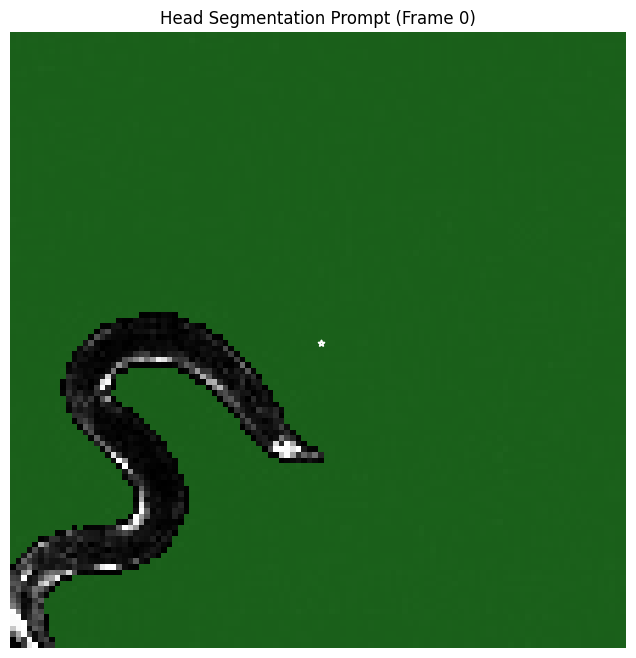

propagate in video: 0it [00:00, ?it/s]

All 1 frames contain valid head masks
Head segmentation saved to ../data/processed_files/RIA_calcium_imaging/head_segmentation_outputs/5_t065_ch01_crop_headsegmentation.h5
Head segmentation complete for 5_t065_ch01


In [14]:
# Checking if head segmentation already exists
head_seg_file = head_segmentation_outputs_dir / f'{video_name}_crop_headsegmentation.h5'

if head_seg_file.exists():
    print(f'Head segmentation already exists at {head_seg_file}; skipping.')
else:
    # Initializing the SAM2 predictor on the cropped video frames
    inference_state = predictor.init_state(video_path=crop_video_dir)

    # Prompting at the center of a frame near the end of the video
    crop_frame_list = sorted(
        [p for p in os.listdir(crop_video_dir) if p.lower().endswith(('.jpg', '.jpeg'))],
        key=lambda p: int(os.path.splitext(p)[0])
    )
    ann_frame_idx = min(512, len(crop_frame_list) - 1)
    first_frame_img = cv2.imread(os.path.join(crop_video_dir, crop_frame_list[ann_frame_idx]))
    h, w = first_frame_img.shape[:2]

    ann_obj_id = 2
    points = np.array([[w // 2, h // 2]], dtype=np.float32)
    labels = np.array([1], np.int32)

    _, out_obj_ids, out_mask_logits = predictor.add_new_points(
        inference_state=inference_state,
        frame_idx=ann_frame_idx,
        obj_id=ann_obj_id,
        points=points,
        labels=labels,
    )

    # Visualizing the head segmentation prompt
    plt.figure(figsize=(8, 8))
    plt.imshow(Image.open(os.path.join(crop_video_dir, crop_frame_list[ann_frame_idx])))
    show_points(points, labels, plt.gca())
    for i, out_obj_id in enumerate(out_obj_ids):
        show_mask((out_mask_logits[i] > 0.0).cpu().numpy(), plt.gca(), obj_id=out_obj_id)
    plt.title(f'Head Segmentation Prompt (Frame {ann_frame_idx})')
    plt.axis('off')
    plt.show()

    # Propagating the mask backward through all frames
    head_video_segments = {}
    head_video_segments[ann_frame_idx] = {
        out_obj_id: (out_mask_logits[i] > 0.0).cpu().numpy()
        for i, out_obj_id in enumerate(out_obj_ids)
    }

    for out_frame_idx, out_obj_ids_prop, out_mask_logits_prop in predictor.propagate_in_video(
        inference_state, start_frame_idx=ann_frame_idx, reverse=True
    ):
        head_video_segments[out_frame_idx] = {
            out_obj_id: (out_mask_logits_prop[i] > 0.0).cpu().numpy()
            for i, out_obj_id in enumerate(out_obj_ids_prop)
        }

    # Validating that all frames have valid masks
    all_ok = True
    for fidx, fmasks in head_video_segments.items():
        if ann_obj_id not in fmasks:
            print(f'Warning: Object {ann_obj_id} missing in frame {fidx}')
            all_ok = False
        elif not np.any(fmasks[ann_obj_id]):
            print(f'Warning: Empty mask for object {ann_obj_id} in frame {fidx}')
            all_ok = False
    if all_ok:
        print(f'All {len(head_video_segments)} frames contain valid head masks')

    # Saving head segmentation to H5
    head_crop_name = f'{video_name}_crop'
    save_head_segments_to_h5(head_video_segments, head_crop_name, head_segmentation_outputs_dir)

    print(f'Head segmentation complete for {video_name}')

## Extracting Head Angles
From the head segmentation masks, we extract skeleton-based head angle measurements, apply smoothing to remove noise, and correct for the worm's left/right orientation.

### Creating Helper Functions for Head Angle Extraction

In [15]:
# Creating skeletons from binary masks
def process_all_skeleton_frames(head_segments):
    skeletons = {}
    for frame_idx, frame_data in head_segments.items():
        frame_skeletons = {}
        for obj_id, mask in frame_data.items():
            mask_2d = mask.squeeze() if mask.ndim > 2 else mask
            frame_skeletons[obj_id] = skeletonize(mask_2d)
        skeletons[frame_idx] = frame_skeletons
    print(f'Skeletonized {len(skeletons)} frames')
    return skeletons


# Truncating skeletons to keep only the top portion
def truncate_skeleton_fixed(skeleton_dict, keep_pixels=150):
    truncated_skeletons = {}
    for frame_idx, frame_data in skeleton_dict.items():
        frame_truncated = {}
        for obj_id, skeleton in frame_data.items():
            skeleton_2d = skeleton[0] if skeleton.ndim > 2 else skeleton
            points = np.where(skeleton_2d)
            if len(points[0]) == 0:
                frame_truncated[obj_id] = skeleton
                continue

            y_min = np.min(points[0])
            cutoff_point = y_min + keep_pixels + 1

            truncated = skeleton.copy()
            if truncated.ndim > 2:
                truncated[0, cutoff_point:, :] = False
            else:
                truncated[cutoff_point:, :] = False
            frame_truncated[obj_id] = truncated
        truncated_skeletons[frame_idx] = frame_truncated
    return truncated_skeletons


# Resampling skeleton points to uniform spacing
def normalize_skeleton_points(points, num_points=100):
    dists = np.sqrt(np.sum(np.diff(points, axis=0)**2, axis=1))
    cum_dists = np.concatenate(([0], np.cumsum(dists)))
    total_length = cum_dists[-1]

    even_dists = np.linspace(0, total_length, num_points)
    new_points = np.zeros((num_points, 2))
    for i in range(2):
        new_points[:, i] = np.interp(even_dists, cum_dists, points[:, i])
    return new_points, total_length


# Computing curvature with Gaussian-weighted windows
def gaussian_weighted_curvature(points, window_size=25, sigma=8, restriction_point=0.5):
    valid_points = points[:int(len(points) * restriction_point)]
    smooth_points = np.zeros_like(valid_points)
    for i in range(2):
        smooth_points[:, i] = gaussian_filter1d(valid_points[:, i], sigma=sigma / 2)

    window_size = window_size if window_size % 2 == 1 else window_size + 1
    pad_width = window_size // 2
    padded_points = np.pad(smooth_points, ((pad_width, pad_width), (0, 0)), mode='edge')

    weights = gaussian_filter1d(np.ones(window_size), sigma)
    weights /= np.sum(weights)

    curvatures = []
    for i in range(len(smooth_points)):
        window = padded_points[i:i + window_size]
        centroid = np.sum(window * weights[:, np.newaxis], axis=0) / np.sum(weights)
        centered = window - centroid
        cov = np.dot(centered.T, centered * weights[:, np.newaxis]) / np.sum(weights)
        eigvals = la.eigvalsh(cov)
        curvatures.append(eigvals[0] / (eigvals[1] + 1e-10))

    full_curvatures = np.zeros(len(points))
    full_curvatures[:len(curvatures)] = curvatures
    return full_curvatures


# Calculating head angle and bend location from a skeleton
def calculate_head_angle(skeleton, prev_angle=None, min_vector_length=5,
                         restriction_point=0.4, straight_threshold=3):
    default_result = {
        'angle_degrees': prev_angle if prev_angle is not None else 0,
        'head_mag': 0, 'body_mag': 0,
        'bend_location': 0, 'bend_magnitude': 0, 'bend_position': [0, 0],
        'skeleton_points': [[0, 0]], 'curvature_profile': [0],
        'head_start_pos': [0, 0], 'head_end_pos': [0, 0],
        'body_start_pos': [0, 0], 'body_end_pos': [0, 0],
        'head_vector': [0, 0], 'body_vector': [0, 0],
        'is_straight': True, 'error': None,
    }

    try:
        points = np.column_stack(np.where(skeleton))
        if len(points) == 0:
            default_result['error'] = 'Empty skeleton'
            return default_result

        ordered_points = points[np.argsort(points[:, 0])]
        norm_points, _ = normalize_skeleton_points(ordered_points, num_points=100)

        head_sections = [0.05, 0.08, 0.1, 0.15]
        body_section = 0.3
        best_result = None
        max_angle_magnitude = 0

        for head_section in head_sections:
            head_end_idx = max(2, int(head_section * len(norm_points)))
            body_start_idx = int((1 - body_section) * len(norm_points))

            head_vector = norm_points[head_end_idx] - norm_points[0]
            body_vector = norm_points[-1] - norm_points[body_start_idx]

            head_mag = np.linalg.norm(head_vector)
            body_mag = np.linalg.norm(body_vector)

            if head_mag < min_vector_length or body_mag < min_vector_length:
                continue

            dot_product = np.dot(head_vector, body_vector)
            cos_angle = np.clip(dot_product / (head_mag * body_mag), -1.0, 1.0)
            angle_deg = np.degrees(np.arccos(cos_angle))

            if np.cross(body_vector, head_vector) < 0:
                angle_deg = -angle_deg

            if prev_angle is not None and abs(angle_deg - prev_angle) > 25:
                continue

            if abs(angle_deg) > max_angle_magnitude:
                max_angle_magnitude = abs(angle_deg)
                best_result = {
                    'angle_degrees': float(angle_deg),
                    'head_start_pos': norm_points[0].tolist(),
                    'head_end_pos': norm_points[head_end_idx].tolist(),
                    'body_start_pos': norm_points[body_start_idx].tolist(),
                    'body_end_pos': norm_points[-1].tolist(),
                    'head_vector': head_vector.tolist(),
                    'body_vector': body_vector.tolist(),
                    'head_mag': float(head_mag),
                    'body_mag': float(body_mag),
                    'skeleton_points': norm_points.tolist(),
                    'error': None,
                }

        if best_result is None:
            default_result['error'] = 'No valid angle found'
            return default_result

        # Computing bend values based on straightness
        if abs(best_result['angle_degrees']) <= straight_threshold:
            best_result.update({
                'bend_location': 0, 'bend_magnitude': 0, 'bend_position': [0, 0],
                'curvature_profile': np.zeros(len(norm_points)).tolist(),
                'is_straight': True,
            })
        else:
            curvatures = gaussian_weighted_curvature(norm_points, restriction_point=restriction_point)
            valid_range = int(len(curvatures) * restriction_point)
            max_idx = np.argmax(np.abs(curvatures[:valid_range]))
            best_result.update({
                'bend_location': max_idx / len(curvatures),
                'bend_magnitude': float(np.abs(curvatures[max_idx])),
                'bend_position': norm_points[max_idx].tolist(),
                'curvature_profile': curvatures.tolist(),
                'is_straight': False,
            })

        return best_result

    except Exception as e:
        default_result['error'] = f'Unexpected error: {str(e)}'
        return default_result


# Smoothing head angle noise peaks
def smooth_head_angles(angles, window_size=3, deviation_threshold=15):
    angles = np.array(angles)
    smoothed = angles.copy()
    peaks_detected = []

    for i in range(len(angles)):
        if i < window_size:
            w_before = angles[:i]
            w_after = angles[i + 1:i + 1 + window_size]
        elif i >= len(angles) - window_size:
            w_before = angles[i - window_size:i]
            w_after = angles[i + 1:]
        else:
            w_before = angles[i - window_size:i]
            w_after = angles[i + 1:i + 1 + window_size]

        if len(w_before) == 0 or len(w_after) == 0:
            continue

        mean_before, std_before = np.mean(w_before), np.std(w_before)
        mean_after, std_after = np.mean(w_after), np.std(w_after)

        if (abs(angles[i] - mean_before) > deviation_threshold and
                abs(angles[i] - mean_after) > deviation_threshold and
                std_before < 10 and std_after < 10):
            w_b = 1 / (std_before + 1e-6)
            w_a = 1 / (std_after + 1e-6)
            new_value = (mean_before * w_b + mean_after * w_a) / (w_b + w_a)
            peaks_detected.append((i, angles[i], new_value))
            smoothed[i] = new_value

    return smoothed, peaks_detected


# Applying smoothing to a DataFrame grouped by object ID
def smooth_head_angles_df(df, window_size=3, deviation_threshold=15):
    result_df = df.copy()
    result_df['is_noise_peak'] = False
    result_df['peak_deviation'] = 0.0

    for obj_id in df['object_id'].unique():
        obj_mask = df['object_id'] == obj_id
        obj_angles = df.loc[obj_mask, 'angle_degrees'].values
        smoothed, peaks = smooth_head_angles(obj_angles, window_size, deviation_threshold)
        result_df.loc[obj_mask, 'angle_degrees'] = smoothed

        for idx, orig_val, new_val in peaks:
            df_idx = df.loc[obj_mask].iloc[idx].name
            result_df.loc[df_idx, 'is_noise_peak'] = True
            result_df.loc[df_idx, 'peak_deviation'] = abs(orig_val - new_val)

    return result_df


# Processing all skeletons into head angle measurements
def process_skeleton_batch(truncated_skeletons, min_vector_length=5,
                           restriction_point=0.5, straight_threshold=3,
                           smoothing_window=3, deviation_threshold=15):
    initial_data = []
    frame_results = {}

    # First pass: calculating angles for each frame
    for frame_idx in sorted(truncated_skeletons.keys()):
        frame_data = truncated_skeletons[frame_idx]
        frame_results[frame_idx] = {}

        for obj_id, skeleton_data in frame_data.items():
            skel = skeleton_data[0] if skeleton_data.ndim > 2 else skeleton_data
            result = calculate_head_angle(
                skel, prev_angle=None,
                min_vector_length=min_vector_length,
                restriction_point=restriction_point,
                straight_threshold=straight_threshold,
            )
            frame_results[frame_idx][obj_id] = result

    # Second pass: interpolating failed frames from nearest valid neighbors
    all_frames = sorted(frame_results.keys())
    for frame_idx in all_frames:
        for obj_id in frame_results[frame_idx]:
            result = frame_results[frame_idx][obj_id]
            if result['error'] is not None:
                prev_result = next(
                    (frame_results[f][obj_id] for f in range(frame_idx - 1, -1, -1)
                     if f in frame_results and obj_id in frame_results[f]
                     and frame_results[f][obj_id]['error'] is None),
                    None,
                )
                next_result = next(
                    (frame_results[f][obj_id] for f in range(frame_idx + 1, max(all_frames) + 1)
                     if f in frame_results and obj_id in frame_results[f]
                     and frame_results[f][obj_id]['error'] is None),
                    None,
                )

                if prev_result and next_result:
                    interpolated_angle = (prev_result['angle_degrees'] + next_result['angle_degrees']) / 2
                    frame_results[frame_idx][obj_id]['angle_degrees'] = interpolated_angle
                elif prev_result:
                    frame_results[frame_idx][obj_id]['angle_degrees'] = prev_result['angle_degrees']
                elif next_result:
                    frame_results[frame_idx][obj_id]['angle_degrees'] = next_result['angle_degrees']

            initial_data.append({
                'frame': frame_idx,
                'object_id': obj_id,
                'angle_degrees': frame_results[frame_idx][obj_id]['angle_degrees'],
                'bend_location': frame_results[frame_idx][obj_id]['bend_location'],
                'bend_magnitude': frame_results[frame_idx][obj_id]['bend_magnitude'],
                'head_mag': frame_results[frame_idx][obj_id]['head_mag'],
                'body_mag': frame_results[frame_idx][obj_id]['body_mag'],
                'is_straight': frame_results[frame_idx][obj_id].get('is_straight', True),
                'error': frame_results[frame_idx][obj_id].get('error'),
            })

    # Applying smoothing to the angle measurements
    initial_df = pd.DataFrame(initial_data)
    smoothed_df = smooth_head_angles_df(
        initial_df, window_size=smoothing_window, deviation_threshold=deviation_threshold
    )

    straight_count = smoothed_df[smoothed_df['is_straight'] == True].shape[0]
    non_straight_with_bends = smoothed_df[
        (smoothed_df['is_straight'] == False) & (smoothed_df['bend_location'] > 0)
    ].shape[0]
    print(f'Straight frames: {straight_count}, Non-straight with bend values: {non_straight_with_bends}')

    return smoothed_df


# Merging head angles with brightness data and applying side correction
def save_head_angles_with_side_correction(filename, results_df, final_data_dir_str):
    base_name = os.path.basename(filename).replace('_headsegmentation.h5', '')
    final_data_base = base_name + '_riasegmentation'

    final_data_path = os.path.join(final_data_dir_str, final_data_base + '.csv')
    final_df = pd.read_csv(final_data_path)

    merged_df = pd.merge(
        final_df, results_df,
        left_on='frame', right_on='frame',
        how='left', suffixes=('_old', '')
    )

    # Dropping duplicated columns from merge
    for col in list(merged_df.columns):
        if col.endswith('_old'):
            merged_df.drop(columns=[col], inplace=True)

    # Applying side correction to head angles
    merged_df['angle_degrees_corrected'] = merged_df.apply(
        lambda row: -row['angle_degrees'] if row.get('side_position') == 'right' else row['angle_degrees'],
        axis=1,
    )

    output_path = os.path.join(final_data_dir_str, final_data_base + '_headangles.csv')
    merged_df.to_csv(output_path, index=False)

    print(f'Saved merged head angle data to {output_path}')
    print(f'Shape: {merged_df.shape}, Columns: {merged_df.columns.tolist()}')
    return merged_df

### Processing and Saving Head Angles

In [16]:
# Loading head segmentation data
head_seg_path = str(head_segmentation_outputs_dir / f'{video_name}_crop_headsegmentation.h5')
head_segments = load_cleaned_segments_from_h5(head_seg_path)

# Creating skeletons from head masks
skeletons = process_all_skeleton_frames(head_segments)

# Truncating skeletons to retain only the top portion
truncated_skeletons = truncate_skeleton_fixed(skeletons, keep_pixels=400)

# Processing all skeletons into head angle measurements
results_df = process_skeleton_batch(
    truncated_skeletons,
    min_vector_length=5,
    restriction_point=0.5,
    straight_threshold=3,
    smoothing_window=3,
    deviation_threshold=12,
)

print(f'Head angle results: {results_df.shape[0]} measurements')
print(results_df.describe())

# Merging head angles with brightness data and saving
merged_df = save_head_angles_with_side_correction(
    head_seg_path, results_df, str(final_data_dir)
)

print(f'\nPipeline complete for video: {video_name}')
merged_df.head()

1 frames loaded from ../data/processed_files/RIA_calcium_imaging/head_segmentation_outputs/5_t065_ch01_crop_headsegmentation.h5
Skeletonized 1 frames
Straight frames: 0, Non-straight with bend values: 1
Head angle results: 1 measurements
       frame  object_id  angle_degrees  bend_location  bend_magnitude  \
count    1.0        1.0       1.000000           1.00         1.00000   
mean     0.0        2.0     123.095201           0.12         0.08528   
std      NaN        NaN            NaN            NaN             NaN   
min      0.0        2.0     123.095201           0.12         0.08528   
25%      0.0        2.0     123.095201           0.12         0.08528   
50%      0.0        2.0     123.095201           0.12         0.08528   
75%      0.0        2.0     123.095201           0.12         0.08528   
max      0.0        2.0     123.095201           0.12         0.08528   

        head_mag   body_mag  peak_deviation  
count   1.000000   1.000000             1.0  
mean   47.50

/var/folders/gz/mzdhdnzx0mg7p15jfr2y38k40000gn/T/ipykernel_7895/2324157045.py:125: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  if np.cross(body_vector, head_vector) < 0:


,frame,2,2_bg_corrected,2_pixel_count,3,3_bg_corrected,3_pixel_count,4,4_bg_corrected,4_pixel_count,...,angle_degrees,bend_location,bend_magnitude,head_mag,body_mag,is_straight,error,is_noise_peak,peak_deviation,angle_degrees_corrected
0,0,0.861259,NaN,11107,0.860731,NaN,11108,0.860065,NaN,11098,...,123.095201,0.12,0.08528,47.509585,42.609676,False,None,False,0.0,-123.095201
